In [1]:
import prepare_data
from aug_torchdataset import SegmentationDataset, get_train_augs, get_valid_augs, get_test_augs
from utils import train_fn, visualize_sample, plot_loss
from model import SegmentationModel
from evaluation import evaluate_metrics
from active_learning import active_learning_loop
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import os

/home/stu4/s8/mc6044/miniconda3/envs/idai780/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]="16"

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 50
LR = 0.001
IMAGE_SIZE = 256
BATCH_SIZE = 16

ENCODER = 'efficientnet-b4'
WEIGHTS = 'imagenet'

UNLABELLED_SPLIT = .50

EPOCHS_AL_INITIAL = 30

STRATEGY = 'model_change' # 'uncertainty' # 'model_change'
UNCERTAINTY_MODE = 'mean' # 'topk' # 'max' #'mean'
TOPK_K = 5000

AL_BUDGET_PER_ITER = 20
AL_MAX_ITERATIONS = 25
AL_EPOCHS_PER_ITER = 2
AL_N_SHOW = 1

In [4]:
base_dir = "src"

zip_path = f"./{base_dir}/KolektorSDD2.zip"
extract_path=f"./{base_dir}/"

train_images_path = f"./{base_dir}/train_images"
train_masks_path = f"./{base_dir}/train_masks"
test_images_path = f"./{base_dir}/test_images"
test_masks_path = f"./{base_dir}/test_masks"

train_csv = f"./{base_dir}/train_data.csv"
test_csv = f"./{base_dir}/test_data.csv"

os.makedirs(f"./{base_dir}/model", exist_ok=True)
os.makedirs(f"./{base_dir}/figure", exist_ok=True)
os.makedirs(f"./{base_dir}/results", exist_ok=True)

In [5]:
# extract_zip(zip_path = zip_path, extract_path=f"./{base_dir}/")
# organize_files(base_dir = f"./{base_dir}/")
# create_csv("./data/train_images", "./data/train_masks", "./data/train_data.csv")
# create_csv("./data/test_images", "./data/test_masks", "./data/test_data.csv")

# LOOK OUT!!!!!!!!!!

In [6]:
df_train_full = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

In [7]:
train_df_labelled, train_df_unlabelled = train_test_split(df_train_full, test_size=UNLABELLED_SPLIT)

print(f'Total Train Data: {len(df_train_full)}\n')
print(f'Unlablled Train Data for Active Learning: {len(train_df_unlabelled)}')
print(f'Lablled Train Data for Active Learning: {len(train_df_labelled)}\n')
print(f'Total Test Data: {len(test_df)}')

Total Train Data: 2331

Unlablled Train Data for Active Learning: 1166
Lablled Train Data for Active Learning: 1165

Total Test Data: 1004


Shape of Image: (645, 229, 3) & Shape of Mask: (645, 229)



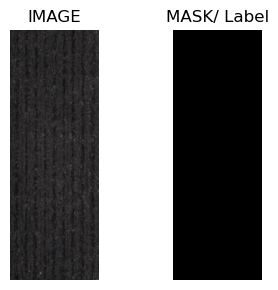

In [8]:
visualize_sample(df_train_full, 0)

In [9]:
full_trainset = SegmentationDataset(df_train_full, get_train_augs())
labelled_trainset = SegmentationDataset(train_df_labelled, get_train_augs())
unlabelled_trainset = SegmentationDataset(train_df_unlabelled, get_valid_augs())
testset = SegmentationDataset(test_df, get_test_augs())

In [10]:
full_trainloader = DataLoader(full_trainset, batch_size=BATCH_SIZE, shuffle=True)
labelled_trainloader = DataLoader(labelled_trainset, batch_size=BATCH_SIZE)
unlabelled_trainloader = DataLoader(unlabelled_trainset, batch_size=BATCH_SIZE)
testloader = DataLoader(testset, batch_size=BATCH_SIZE)

In [11]:
for image, mask in full_trainloader:
  break
print(f"one batch image shape : {image.shape}")
print(f"one batch mask shape : {mask.shape}") 

one batch image shape : torch.Size([16, 3, 256, 256])
one batch mask shape : torch.Size([16, 1, 256, 256])


In [12]:
baseline_model = SegmentationModel()
baseline_model.to(DEVICE);
optimizer = optim.Adam(baseline_model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [13]:
train_losses_baseline = []

print("Training baseline model on full training data...")
for i in range(EPOCHS):
    train_loss = train_fn(full_trainloader, baseline_model, optimizer)
    train_losses_baseline.append(train_loss)
    scheduler.step(train_loss)
    
    # Optional: Print current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {i+1}: Train Loss: {train_loss:.4f}, Learning Rate: {current_lr:.6f}")

# Save the model after all epochs are complete using base_dir
model_save_path_baseline = f"./{base_dir}/model/baseline_model.pt"
torch.save(baseline_model.state_dict(), model_save_path_baseline)
print("Model saved after training completion")

Training baseline model on full training data...


100%|█████████████████████████████████████████████████████████████████████████████████| 146/146 [02:26<00:00,  1.00s/it]


Epoch 1: Train Loss: 0.6120, Learning Rate: 0.001000


100%|█████████████████████████████████████████████████████████████████████████████████| 146/146 [02:25<00:00,  1.01it/s]


Epoch 2: Train Loss: 0.3817, Learning Rate: 0.001000


...

Epoch 48: Train Loss: 0.2085, Learning Rate: 0.000000


100%|█████████████████████████████████████████████████████████████████████████████████| 146/146 [02:23<00:00,  1.02it/s]


Epoch 49: Train Loss: 0.2353, Learning Rate: 0.000000


100%|█████████████████████████████████████████████████████████████████████████████████| 146/146 [02:23<00:00,  1.02it/s]


Epoch 50: Train Loss: 0.2388, Learning Rate: 0.000000
Model saved after training completion


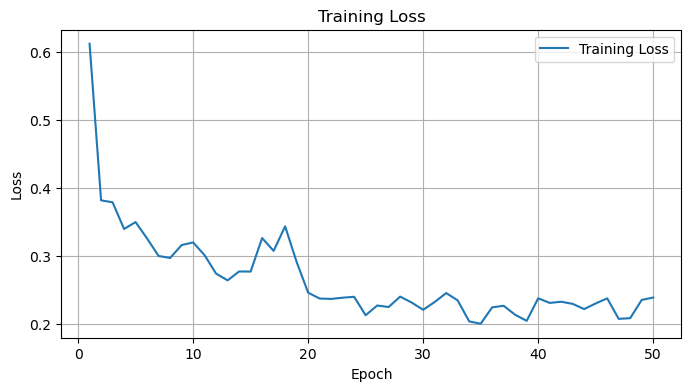

In [14]:
figure_save_path = f"./{base_dir}/figure/baseline_model_loss.jpg"
plot_loss(train_losses_baseline, save_path = figure_save_path)

In [15]:
baseline_metrics = evaluate_metrics(testloader, baseline_model);

100%|███████████████████████████████████████████████████████████████████████████████████| 63/63 [00:21<00:00,  2.87it/s]


Model Evaluation Metrics:
------------------------------
Metric            Value
------------------------------
IoU              0.6158
Dice             0.7132
Accuracy         0.9988
Precision        0.7984
Recall           0.7794
------------------------------


In [16]:
al_model_initial = SegmentationModel()
al_model_initial.to(DEVICE)
optimizer = optim.Adam(al_model_initial.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [17]:
train_losses_al_initial = []

print("Training baseline model on full training data...")
for i in range(EPOCHS_AL_INITIAL):
    train_loss = train_fn(labelled_trainloader, al_model_initial, optimizer)
    train_losses_al_initial.append(train_loss)
    scheduler.step(train_loss)
    
    # Optional: Print current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {i+1}: Train Loss: {train_loss:.4f}, Learning Rate: {current_lr:.6f}")

# Save the model after all epochs are complete using base_dir
model_save_path_al_initial = f"./{base_dir}/model/al_model_initial.pt"
torch.save(al_model_initial.state_dict(), model_save_path_al_initial)

Training baseline model on full training data...


100%|███████████████████████████████████████████████████████████████████████████████████| 73/73 [01:12<00:00,  1.01it/s]


Epoch 1: Train Loss: 0.8355, Learning Rate: 0.001000


100%|███████████████████████████████████████████████████████████████████████████████████| 73/73 [01:12<00:00,  1.01it/s]


Epoch 2: Train Loss: 0.7095, Learning Rate: 0.001000


...

Epoch 28: Train Loss: 0.2419, Learning Rate: 0.001000


100%|███████████████████████████████████████████████████████████████████████████████████| 73/73 [01:11<00:00,  1.02it/s]


Epoch 29: Train Loss: 0.2140, Learning Rate: 0.001000


100%|███████████████████████████████████████████████████████████████████████████████████| 73/73 [01:11<00:00,  1.02it/s]


Epoch 30: Train Loss: 0.2036, Learning Rate: 0.001000


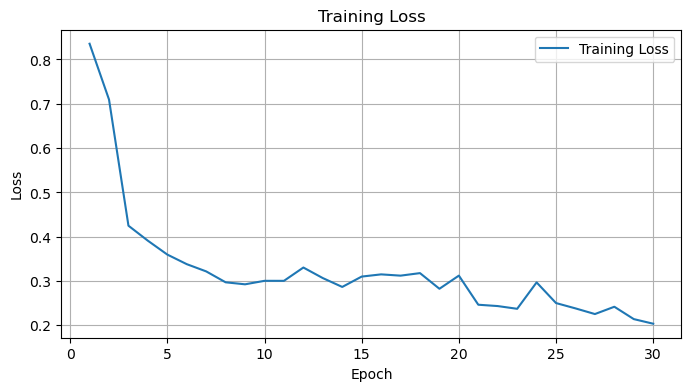

In [18]:
figure_save_path = f"./{base_dir}/figure/al_initial_model_loss.jpg"
plot_loss(train_losses_al_initial, save_path = figure_save_path)

In [19]:
# Load initial al model
al_model_initial = SegmentationModel()
model_save_path_al_initial = f"./{base_dir}/model/al_model_initial.pt"
al_model_initial.load_state_dict(torch.load(model_save_path_al_initial, map_location=DEVICE, weights_only=True))
al_model_initial.to(DEVICE);

In [20]:
al_model = active_learning_loop(al_model_initial,  labeled_df=train_df_labelled, unlabeled_df=train_df_unlabelled,
                                budget_per_iter=AL_BUDGET_PER_ITER, max_iterations=AL_MAX_ITERATIONS, 
                                epochs_per_iter=AL_EPOCHS_PER_ITER, n_show=0, strategy=STRATEGY,
                                uncertainty_mode=UNCERTAINTY_MODE, topk_k=TOPK_K)

model_save_path_al = f"./{base_dir}/model/al_model.pt"
torch.save(al_model.state_dict(), model_save_path_al)


Active Learning Iteration 1/25


Computing expected model change: 100%|██████████████████████████████████████████████████| 73/73 [01:08<00:00,  1.06it/s]



Displaying top 0 samples with highest gradient norm ():
Selected 20 samples for labeling.


100%|███████████████████████████████████████████████████████████████████████████████████| 75/75 [01:13<00:00,  1.02it/s]


Iteration 1, Epoch 1/2 - Train Loss: 0.2666


...


Displaying top 0 samples with highest gradient norm ():
Selected 20 samples for labeling.


100%|█████████████████████████████████████████████████████████████████████████████████| 105/105 [01:42<00:00,  1.02it/s]


Iteration 25, Epoch 1/2 - Train Loss: 0.2035


100%|█████████████████████████████████████████████████████████████████████████████████| 105/105 [01:42<00:00,  1.02it/s]


Iteration 25, Epoch 2/2 - Train Loss: 0.2241


In [21]:
active_learning_metrics = evaluate_metrics(testloader, al_model)

100%|███████████████████████████████████████████████████████████████████████████████████| 63/63 [00:21<00:00,  2.90it/s]


Model Evaluation Metrics:
------------------------------
Metric            Value
------------------------------
IoU              0.6637
Dice             0.7591
Accuracy         0.9987
Precision        0.8866
Recall           0.7372
------------------------------


In [22]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

log_file_path = f"./{base_dir}/results/training_log.txt"

with open(log_file_path, 'a') as log_file:  
    log_file.write(f"\nRun at {timestamp}\n")
    log_file.write("========================================\n\n")
    
    log_file.write("Baseline and Active Learning Model Hyperparameters:\n")
    log_file.write(f"Device: {DEVICE}\n")
    log_file.write(f"Learning Rate (LR): {LR}\n")
    log_file.write(f"Image Size: {IMAGE_SIZE}\n")
    log_file.write(f"Batch Size: {BATCH_SIZE}\n")
    log_file.write(f"Encoder: {ENCODER}\n")
    log_file.write(f"Weights: {WEIGHTS}\n")
    log_file.write(f"Baseline Epochs (EPOCHS): {EPOCHS}\n")
    log_file.write(f"Initial Active Learning Epochs (EPOCHS_AL_INITIAL): {EPOCHS_AL_INITIAL}\n")
    log_file.write(f"Active Learning Budget per Iteration: {AL_BUDGET_PER_ITER}\n")
    log_file.write(f"Active Learning Max Iterations: {AL_MAX_ITERATIONS}\n")
    log_file.write(f"Active Learning Epochs per Iteration: {AL_EPOCHS_PER_ITER}\n")
    log_file.write(f"Active Learning N Show: {AL_N_SHOW}\n")
    log_file.write(f"Active Learning Test Size for Unlabelled Split: {UNLABELLED_SPLIT}\n\n")
    
    log_file.write("Active Learning Query Strategy:\n")
    log_file.write(f"Strategy for query/sample selection: {STRATEGY}\n")
    log_file.write(f"Uncertainty calculatin mode for uncertainty strategy (mean/max/topk): {UNCERTAINTY_MODE}\n")
    log_file.write(f"Top n number of samples for uncertainty strategy and topk uncertainty mode : {TOPK_K}\n\n")
    
    log_file.write("Data Split:\n") 
    log_file.write(f"Total Training Data: {len(df_train_full)}\n")
    log_file.write(f"Labeled Training Data: {len(train_df_labelled)}\n")
    log_file.write(f"Unlabeled Training Data: {len(train_df_unlabelled)}\n")
    log_file.write(f"Test Data: {len(test_df)}\n\n")
    
    log_file.write("Training Losses:\n")
    log_file.write("Baseline Model Losses per Epoch:\n")
    for i, loss in enumerate(train_losses_baseline):
        log_file.write(f"Epoch {i+1}: {loss:.4f}\n")
    log_file.write("Initial Active Learning Model Losses per Epoch:\n")
    for i, loss in enumerate(train_losses_al_initial):
        log_file.write(f"Epoch {i+1}: {loss:.4f}\n")
    log_file.write("\n")
    
    log_file.write("Evaluation Metrics:\n")
    log_file.write("Baseline Model:\n")
    for metric_name, value in baseline_metrics.items():
        log_file.write(f"{metric_name}: {value:.4f}\n")
    log_file.write("Active Learning Model:\n")
    for metric_name, value in active_learning_metrics.items():
        log_file.write(f"{metric_name}: {value:.4f}\n")
    log_file.write("\n")  

print(f"Log file updated at: {log_file_path}")

Log file updated at: ./Capstone/results/training_log.txt


In [1]:
import pandas as pd
import re
from collections import defaultdict
import numpy as np

base_dir = "src"
log_file = f"./{base_dir}/results/training_log.txt"

runs_data = []
baseline_metrics = defaultdict(list)

def parse_run(run_text):
    run_data = {}
    
    total_train = int(re.search(r'Total Training Data: (\d+)', run_text).group(1))
    labeled_train = int(re.search(r'Labeled Training Data: (\d+)', run_text).group(1))
    unlabeled_train = int(re.search(r'Unlabeled Training Data: (\d+)', run_text).group(1))
    
    budget_per_iter = int(re.search(r'Active Learning Budget per Iteration: (\d+)', run_text).group(1))
    max_iterations = int(re.search(r'Active Learning Max Iterations: (\d+)', run_text).group(1))
    data_labeled_al = budget_per_iter * max_iterations
    
    strategy = re.search(r'Strategy for query/sample selection: (\w+)', run_text).group(1)
    uncertainty_mode = re.search(r'Uncertainty calculatin mode for uncertainty strategy \(mean/max/topk\): (\w+)', run_text)
    strategy_full = f"{strategy} ({uncertainty_mode.group(1)})" if uncertainty_mode else strategy
    
    al_metrics = {}
    al_metrics['IoU'] = float(re.search(r'Active Learning Model:.*?IoU: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Dice'] = float(re.search(r'Active Learning Model:.*?Dice: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Accuracy'] = float(re.search(r'Active Learning Model:.*?Accuracy: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Precision'] = float(re.search(r'Active Learning Model:.*?Precision: ([\d.]+)', run_text, re.DOTALL).group(1))
    al_metrics['Recall'] = float(re.search(r'Active Learning Model:.*?Recall: ([\d.]+)', run_text, re.DOTALL).group(1))
    
    baseline_metrics_run = {}
    baseline_metrics_run['IoU'] = float(re.search(r'Baseline Model:.*?IoU: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Dice'] = float(re.search(r'Baseline Model:.*?Dice: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Accuracy'] = float(re.search(r'Baseline Model:.*?Accuracy: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Precision'] = float(re.search(r'Baseline Model:.*?Precision: ([\d.]+)', run_text, re.DOTALL).group(1))
    baseline_metrics_run['Recall'] = float(re.search(r'Baseline Model:.*?Recall: ([\d.]+)', run_text, re.DOTALL).group(1))
    
    
    for metric, value in baseline_metrics_run.items():
        baseline_metrics[metric].append(value)
    
    run_data['Labeled Data'] = labeled_train
    run_data['Unlabeled Data'] = unlabeled_train
    run_data['Data Labeled (AL)'] = data_labeled_al
    run_data['Strategy'] = strategy_full
    run_data['IoU'] = al_metrics['IoU']
    run_data['Dice'] = al_metrics['Dice']
    run_data['Accuracy'] = al_metrics['Accuracy']
    run_data['Precision'] = al_metrics['Precision']
    run_data['Recall'] = al_metrics['Recall']
    
    return run_data

In [2]:
with open(log_file, 'r') as f:
    log_content = f.read()

runs = log_content.split('Run at ')[1:]  
for run in runs:
    run_data = parse_run(run)
    runs_data.append(run_data)

df = pd.DataFrame(runs_data)

avg_baseline = {metric: sum(values) / len(values) for metric, values in baseline_metrics.items()}

baseline_row = {
    'Labeled Data': 2331,
    'Unlabeled Data': 'N/A',
    'Data Labeled (AL)': 'N/A',
    'Strategy': 'Baseline (Average)',
    'IoU': avg_baseline['IoU'],
    'Dice': avg_baseline['Dice'],
    'Accuracy': avg_baseline['Accuracy'],
    'Precision': avg_baseline['Precision'],
    'Recall': avg_baseline['Recall']
}
df = pd.concat([df, pd.DataFrame([baseline_row])], ignore_index=True)

df['G-mean'] = np.sqrt(df['Precision'] * df['Recall'])
df.loc[df['Strategy'].str.contains('model_change'), 'Strategy'] = 'model_change'


pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
df

,Labeled Data,Unlabeled Data,Data Labeled (AL),Strategy,IoU,Dice,Accuracy,Precision,Recall,G-mean
0,1165,1166,500,uncertainty (mean),0.6677,0.7669,0.9986,0.8750,0.7548,0.8127
1,1748,583,500,uncertainty (mean),0.6623,0.7539,0.9989,0.8668,0.7625,0.8130
2,582,1749,1000,uncertainty (mean),0.6756,0.7685,0.9988,0.8780,0.7653,0.8197
3,582,1749,700,uncertainty (mean),0.6732,0.7639,0.9988,0.9139,0.7318,0.8178
4,1165,1166,500,model_change,0.6637,0.7591,0.9987,0.8866,0.7372,0.8085
5,1748,583,500,model_change,0.6421,0.7502,0.9989,0.8518,0.7521,0.8004
6,582,1749,1000,model_change,0.6586,0.7532,0.9985,0.8828,0.7385,0.8074
7,582,1749,700,model_change,0.6542,0.7532,0.9985,0.8140,0.7821,0.7979
8,2331,N/A,N/A,Baseline (Average),0.6390,0.7369,0.9986,0.8260,0.7593,0.7920


In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

df['Unlabeled Data'] = pd.to_numeric(df['Unlabeled Data'], errors='coerce')
df['Data Labeled (AL)'] = pd.to_numeric(df['Data Labeled (AL)'], errors='coerce')

baseline_gmean = df[df['Strategy'] == 'Baseline (Average)']['G-mean'].iloc[0]

def plot_strategy(df, strategy_name, baseline_gmean, save_path):
    
    if strategy_name == 'uncertainty':
        df_strategy = df[df['Strategy'].str.contains('uncertainty')]
    else:
        df_strategy = df[df['Strategy'].str.contains(strategy_name)]
    
    runs = range(len(df_strategy))
    labeled_data = df_strategy['Labeled Data']
    unlabeled_data = df_strategy['Unlabeled Data']
    al_data = df_strategy['Data Labeled (AL)']
    gmeans = df_strategy['G-mean']
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    bar_width = 0.25
    ax1.bar([r - bar_width for r in runs], labeled_data, width=bar_width, label='Labeled Data', color='skyblue')
    ax1.bar(runs, unlabeled_data, width=bar_width, label='Unlabeled Data', color='lightgreen')
    ax1.bar([r + bar_width for r in runs], al_data, width=bar_width, label='Data Labeled (AL)', color='salmon')
    
    ax1.set_xlabel('Run')
    ax1.set_ylabel('Number of Samples')
    ax1.set_title(f'Data Split and G-mean for {strategy_name.capitalize()} Strategy')
    ax1.set_xticks(runs)
    ax1.set_xticklabels([f'Run {i+1}' for i in runs])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(runs, gmeans, marker='o', color='blue', label='G-mean (Strategy)', linewidth=2)
    ax2.axhline(y=baseline_gmean, color='red', linestyle='--', label='G-mean (Baseline)')
    ax2.set_ylabel('G-mean')
    ax2.set_ylim(0.60, 0.99)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    #plt.savefig(save_path)
    #plt.show()
    plt.close()




In [ ]:
import matplotlib
matplotlib.use('Agg')  # Set non-interactive backend
import matplotlib.pyplot as plt
plot_strategy(df, 'uncertainty', baseline_gmean, 'uncertainty_strategy_plot.png')
plot_strategy(df, 'model_change', baseline_gmean, 'model_change_strategy_plot.png')

In [1]:
import matplotlib
print(matplotlib.__version__)

3.10.0
